# 01 — Quickstart

Extract structured data from a PDF invoice in one line of code using DocuFlow and Gemini Flash 2.5.

## How document extraction works

Most document processing follows the same pattern: you have a PDF (or scan, or image), and you need structured data out of it. Traditionally this meant regex, templates, or manual data entry. LLMs changed this by being able to *read* a document and fill in a schema — but raw LLM output is unreliable without guardrails.

DocuFlow wraps this into a **pipeline** with seven stages:

```
Ingest → Parse → Anonymize → Extract → Validate → Review → Store
```

- **Ingest** loads the file and creates a Document object.
- **Parse** converts raw bytes into structured text blocks with bounding boxes — the spatial map of the document.
- **Anonymize** detects and replaces PII (names, emails, credit cards) before the text reaches the LLM. Supports redact, mask, pseudonymize, and hash modes. Optional — skipped if no privacy policy is configured.
- **Extract** sends the parsed content (or page images) to an LLM along with your Pydantic schema. The LLM returns structured JSON, and DocuFlow links every extracted value back to its source text and location on the page.
- **Validate** checks structural correctness — are required fields present? Do they have evidence?
- **Review** applies confidence thresholds and business rules to decide if a human needs to check the result.
- **Store** persists the document, extraction, and full audit trail.

The **Pydantic schema** is central: field names, types, and descriptions become the LLM's extraction instructions. A well-described schema directly improves extraction accuracy. Every extracted field carries **evidence** — the source text, page number, and bounding box where the value was found — so you can always trace back *why* the LLM returned a particular value.

In [1]:
import os

# Set your Gemini API key (or export GEMINI_API_KEY in your shell before launching Jupyter)
os.environ["GEMINI_API_KEY"] = os.environ.get("GEMINI_API_KEY", "<set-your-gemini-api-key>")

PDF_PATH = "data/sample_invoice.pdf"

from pydantic import BaseModel, Field
from typing import Optional, List


class LineItem(BaseModel):
    description: str = Field(description="Line item description")
    quantity: float = Field(description="Quantity")
    unit_price: float = Field(description="Price per unit in USD")
    tax_rate: float = Field(description="Tax rate percentage for this item")
    amount: float = Field(description="Line item total (qty x unit_price)")


class Invoice(BaseModel):
    supplier_name: str = Field(description="Name of the supplier company")
    invoice_number: str = Field(description="Invoice reference number")
    invoice_date: str = Field(description="Date invoice was issued")
    due_date: str = Field(description="Payment due date")
    po_number: str = Field(description="Purchase order reference number")
    currency: str = Field(default="USD", description="Currency code")
    bill_to_company: str = Field(description="Billing company name")
    ship_to_company: str = Field(description="Shipping company name")
    subtotal: float = Field(description="Amount before tax")
    tax_rate: float = Field(description="Tax rate as percentage")
    tax_amount: float = Field(description="Total tax amount")
    total: float = Field(description="Grand total including tax")
    payment_terms: str = Field(description="Payment terms (e.g. Net 30)")
    line_items: List[LineItem] = Field(description="Individual line items")


print(f"Schema loaded: {len(Invoice.model_fields)} top-level fields")
print(f"PDF path: {PDF_PATH}")

Schema loaded: 14 top-level fields
PDF path: data/sample_invoice.pdf


## One-liner extraction

The simplest way to extract structured data: one function call.

In [2]:
from docuflow import extract

result = extract(PDF_PATH, schema=Invoice, model="gemini/gemini-2.5-flash")

print("Extraction complete.")

Extraction complete.


## Inspect the result

In [3]:
print("=== Extracted Data ===")
for key, value in result.data.items():
    if key != "line_items":
        print(f"  {key:<20}: {value!r}")
print(f"  {'line_items':<20}: [{len(result.data.get('line_items', []))} items]")

print()
print(f"Overall confidence : {result.confidence:.2f}")
print(f"Needs review       : {result.needs_review}")
print(f"Review status      : {result.review_status}")

=== Extracted Data ===
  supplier_name       : 'Meridian Dynamics Ltd'
  invoice_number      : '#INV-2024-1847'
  invoice_date        : 'November 15, 2024'
  due_date            : 'December 15, 2024'
  po_number           : 'PO-90281'
  currency            : 'USD'
  bill_to_company     : 'Northwind Traders Inc.'
  ship_to_company     : 'Northwind Traders — Warehouse B'
  subtotal            : 113315.0
  tax_rate            : 8.25
  tax_amount          : 9348.49
  total               : 122663.49
  payment_terms       : 'Net 30'
  line_items          : [15 items]

Overall confidence : 0.89
Needs review       : False
Review status      : pending


## Per-field details

In [4]:
header = f"{'Field':<20} {'Value':<32} {'Conf':>5}  Evidence"
print(header)
print("-" * 90)

for fname, f in result.fields.items():
    if fname == "line_items":
        val_str = f"[{len(f.value)} items]"
    else:
        val_str = str(f.value)[:30]
    ev_text = f.evidence[0].text[:30] if f.evidence else "(none)"
    print(f"  {fname:<18} {val_str:<32} {f.confidence:>5.2f}  {ev_text}")

Field                Value                             Conf  Evidence
------------------------------------------------------------------------------------------
  supplier_name      Meridian Dynamics Ltd             1.00  Meridian Dynamics Ltd
  invoice_number     #INV-2024-1847                    1.00  #INV-2024-1847
  invoice_date       November 15, 2024                 1.00  November 15, 2024
  due_date           December 15, 2024                 1.00  December 15, 2024
  po_number          PO-90281                          1.00  PO-90281
  currency           USD                               0.20  $
  bill_to_company    Northwind Traders Inc.            1.00  Northwind Traders Inc.
  ship_to_company    Northwind Traders — Warehouse     1.00  Northwind Traders — Warehouse 
  subtotal           113315.0                          1.00  $113,315.00
  tax_rate           8.25                              1.00  8.25%
  tax_amount         9348.49                           1.00  $9,348.49
  

## Line items

In [5]:
line_items = result.data.get("line_items", [])

print(f"{'#':<4} {'Description':<40} {'Qty':>6} {'Unit Price':>12} {'Tax %':>7} {'Amount':>12}")
print("-" * 85)

for i, item in enumerate(line_items, 1):
    if isinstance(item, dict):
        desc = item.get("description", "")[:38]
        qty = item.get("quantity", 0)
        up = item.get("unit_price", 0)
        tr = item.get("tax_rate", 0)
        amt = item.get("amount", 0)
    else:
        desc = item.description[:38]
        qty = item.quantity
        up = item.unit_price
        tr = item.tax_rate
        amt = item.amount
    print(f"  {i:<2} {desc:<40} {qty:>6.1f} {up:>12.2f} {tr:>7.2f} {amt:>12.2f}")

print("-" * 85)
print(f"  {len(line_items)} line items extracted")

#    Description                                 Qty   Unit Price   Tax %       Amount
-------------------------------------------------------------------------------------
  1  Enterprise Data Platform License (Annu      1.0     24500.00    8.25     24500.00
  2  Additional User Seats (50-pack)             3.0      2200.00    8.25      6600.00
  3  Premium Support & SLA Package (12 mont      1.0      8750.00    8.25      8750.00
  4  On-site Installation & Configuration       40.0       175.00    8.25      7000.00
  5  Custom API Integration Development        120.0       195.00    8.25     23400.00
  6  Data Migration Service (per TB)            12.0       450.00    8.25      5400.00
  7  Training Workshop — Admin (full day)        3.0      1800.00    0.00      5400.00
  8  Training Workshop — End Users (half da      5.0       950.00    0.00      4750.00
  9  SSL Certificate (Wildcard, 2-year)          2.0       320.00    8.25       640.00
  10 Dedicated Cloud Hosting — Setup Fee    

## Evidence deep-dive

Every extracted field links back to source text, page number, and bounding box.

In [6]:
total_field = result.fields["total"]

print(f"Field: total")
print(f"  Value      : {total_field.value}")
print(f"  Confidence : {total_field.confidence:.2f}")
print()

for i, ev in enumerate(total_field.evidence):
    print(f"  Evidence #{i + 1}:")
    print(f"    Text        : \"{ev.text}\"")
    print(f"    Page number : {ev.page_number}")
    if ev.bbox:
        bb = ev.bbox
        print(f"    Bbox        : x0={bb.x0:.1f}, y0={bb.y0:.1f}, x1={bb.x1:.1f}, y1={bb.y1:.1f}")
    if ev.confidence is not None:
        print(f"    Confidence  : {ev.confidence:.2f}")

Field: total
  Value      : 122663.49
  Confidence : 1.00

  Evidence #1:
    Text        : "$122,663.49"
    Page number : 1
    Bbox        : x0=470.0, y0=208.3, x1=531.2, y1=219.3


## Highlighted renders

`highlight_fields` renders each page that has evidence and draws a colored bounding box for every field. It saves one image per page and returns the file paths.

Saved: /tmp/docuflow_highlights/sample_invoice_page_0_highlighted.png
Saved: /tmp/docuflow_highlights/sample_invoice_page_1_highlighted.png


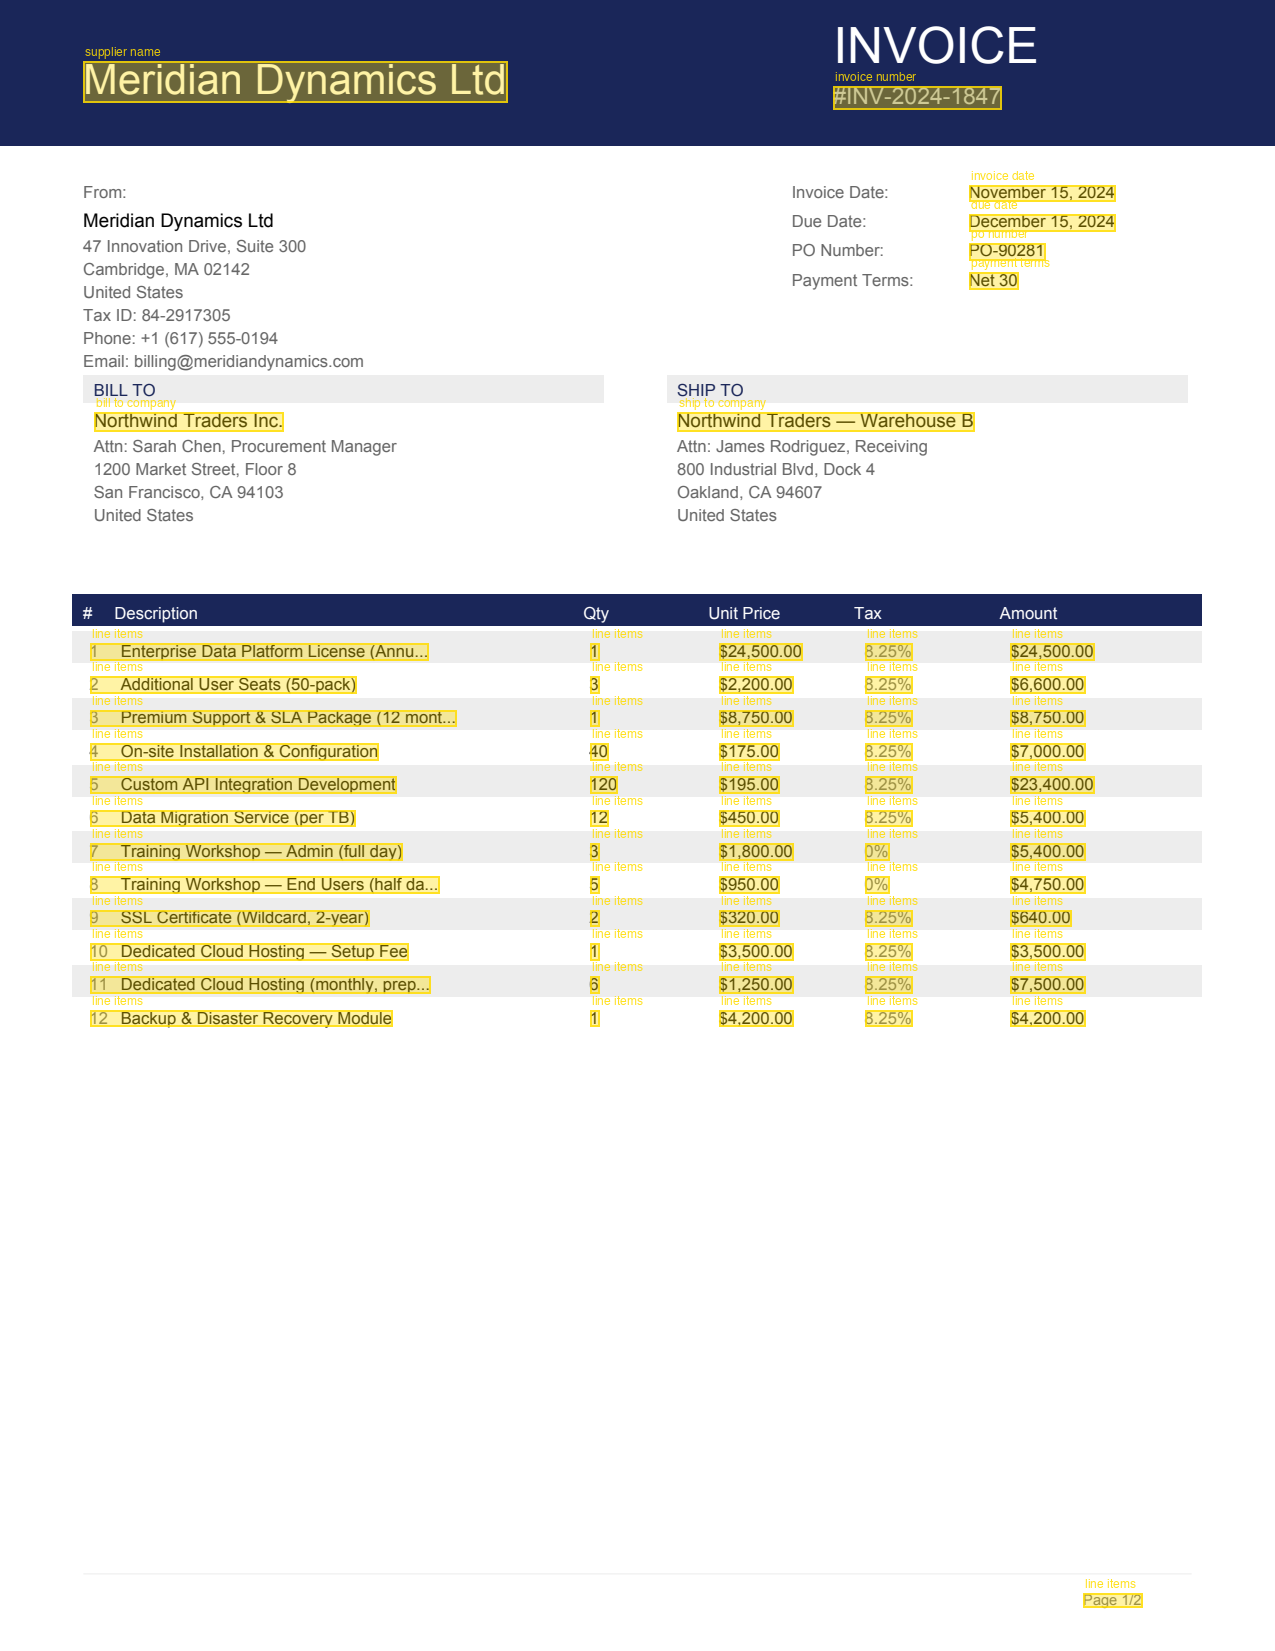

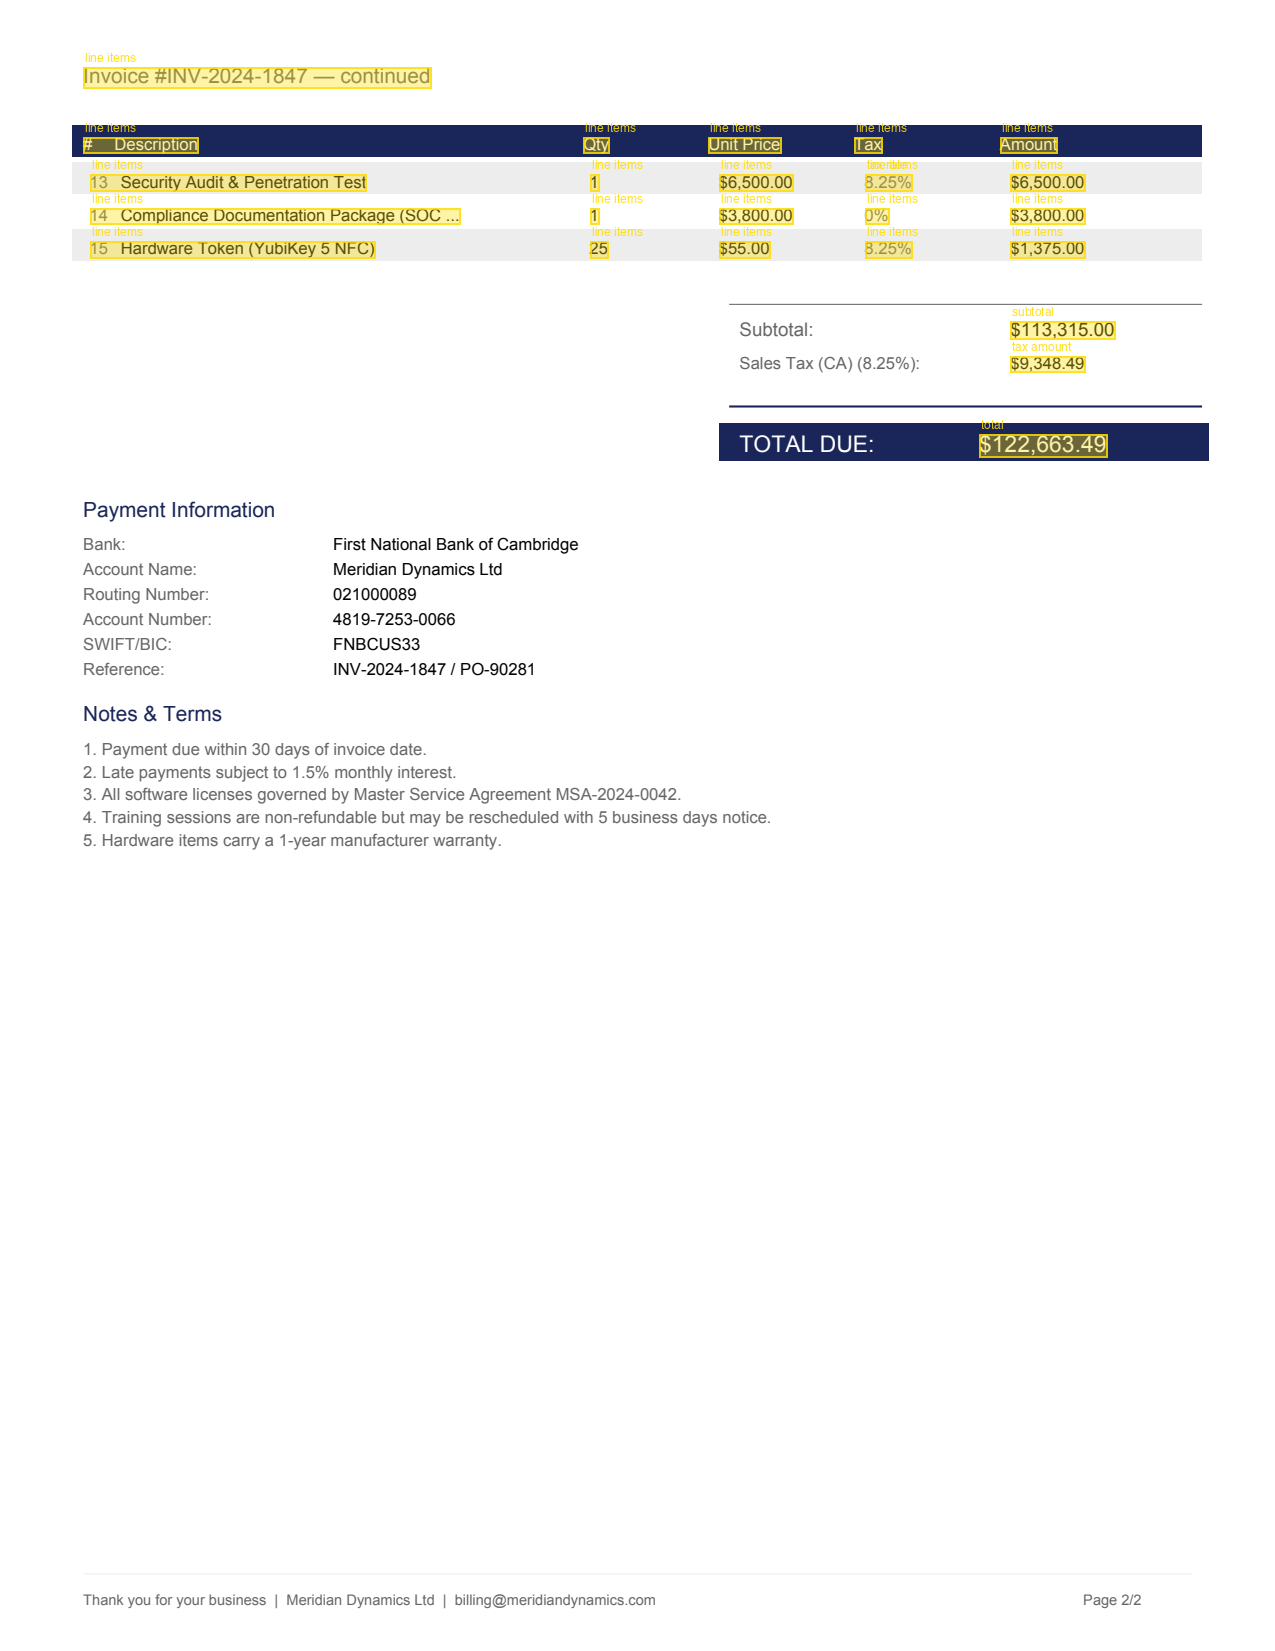

In [7]:
from docuflow import highlight_fields

# Default: semi-transparent yellow highlight for every field
saved_paths = highlight_fields(PDF_PATH, result, output_dir="/tmp/docuflow_highlights")

for p in saved_paths:
    print("Saved:", p)

# Display inline in Jupyter
from IPython.display import Image as IPImage, display
for p in saved_paths:
    display(IPImage(p, width=700))

# --- Optional: customise the highlight color ---
# highlight_fields(PDF_PATH, result, output_dir="/tmp/out", color="cyan")
# highlight_fields(PDF_PATH, result, output_dir="/tmp/out", color=(0, 180, 255, 100))
# highlight_fields(PDF_PATH, result, output_dir="/tmp/out", color="auto")  # distinct color per field
# highlight_fields(PDF_PATH, result, output_dir="/tmp/out", fields=["total", "supplier_name"])

## Pipeline approach

`DocumentPipeline` gives you full control over parser, model, and extraction settings.

In [8]:
from docuflow import DocumentPipeline

pipeline = DocumentPipeline(
    parser="pdfplumber",
    model="gemini/gemini-2.5-flash",
    extraction_mode="single",
)

result2 = pipeline.run_sync(PDF_PATH, schema=Invoice)

print("Pipeline extraction complete.")
print()
print(f"  result2.confidence   : {result2.confidence:.2f}")
print(f"  result2.needs_review : {result2.needs_review}")
print()
print("--- Comparison: extract() vs DocumentPipeline ---")
for key in result.data:
    if key == "line_items":
        n1 = len(result.data.get("line_items", []))
        n2 = len(result2.data.get("line_items", []))
        match = "MATCH" if n1 == n2 else "DIFF"
        print(f"  {key:<20}: {n1} items vs {n2} items  [{match}]")
    else:
        v1 = result.data.get(key)
        v2 = result2.data.get(key)
        match = "MATCH" if v1 == v2 else "DIFF"
        print(f"  {key:<20}: {match}")

Pipeline extraction complete.

  result2.confidence   : 0.89
  result2.needs_review : False

--- Comparison: extract() vs DocumentPipeline ---
  supplier_name       : MATCH
  invoice_number      : MATCH
  invoice_date        : MATCH
  due_date            : MATCH
  po_number           : MATCH
  currency            : MATCH
  bill_to_company     : MATCH
  ship_to_company     : MATCH
  subtotal            : MATCH
  tax_rate            : MATCH
  tax_amount          : MATCH
  total               : MATCH
  payment_terms       : MATCH
  line_items          : 15 items vs 15 items  [MATCH]


## YAML workflow config

Everything you've seen in Python can also be defined in a single YAML file — including per-step configuration for the parser, privacy, storage, and LLM. This makes extraction portable across languages and environments.

```yaml
name: invoice-extraction
version: "1.0"
description: Full invoice pipeline with OCR, anonymization, and storage

schema:
  supplier_name: {type: str, required: true, description: "Supplier company"}
  invoice_number: {type: str, required: true, description: "Invoice number"}
  total: {type: float, required: true, description: "Grand total including tax"}
  currency: {type: str, default: "USD", description: "Currency code"}

parser:
  type: tesseract
  languages: [eng, fra]
  dpi: 300
  preprocess: [deskew, threshold]

model: gemini/gemini-2.5-flash
extraction_mode: multi
n_instances: 3
context: "US invoices. Amounts use comma for thousands, period for decimals."

privacy:
  provider: presidio
  language: en
  mode: pseudonymize
  reversible: true
  fail_closed: true
  entities: [PERSON, EMAIL_ADDRESS, CREDIT_CARD, PHONE_NUMBER]
  score_threshold: 0.4

storage:
  type: local
  path: ./extractions

llm:
  max_retries: 5
  top_p: 0.9

validation:
  - required_fields: [supplier_name, invoice_number, total]
  - evidence_required: [total]

review:
  - overall_confidence_below: 0.7
  - any_field_confidence_below: 0.5

quality_threshold: 0.8
```

```bash
docuflow run invoice.yaml invoice.pdf --output result.json
```

See **07_workflow_config** for the full YAML workflow tutorial including serve and dockerize.

## Next steps

- **02_parsing** — Explore the parsers (pdfplumber, Tesseract, Docling, Smart, plus Azure/AWS/Google cloud OCR) and when to use each.
- **03_privacy_anonymization** — PII detection and anonymization with Presidio: redact, mask, pseudonymize, hash modes.
- **04_extraction** — Text, vision, and hybrid extraction strategies with single and multi-agent modes.
- **05_validation_review** — Validators, review rules, human corrections, and the approval workflow.
- **06_quality_monitoring** — Quality scoring, snapshots, and tracking quality over time.
- **07_workflow_config** — Portable YAML configs, serve as HTTP API, and Docker deployment.
- **08_batch_comparison** — Process folders of documents, route mixed document streams to the right workflow, and compare versions side-by-side.
- **09_advanced** — Schema discovery, search, domain context, and MCP server integration.